# Unilateral AU Detection

__Description:__ This is the work-in-progress notebook for unilateral AU detection model. Existing AU detection models consider the entire face. However, there is value in detecting facial expressions that occur only on one side of the face. An example is the analysis of facial palsy. Also, more complex facial expressions can take place unilaterally. 

__Author:__ Deniz Iren


In [1]:
## Install Mediapipe if not installed
!pip install -q mediapipe==0.10.0

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
## Get the task file. To be used by Mediapipe.
import urllib.request
urllib.request.urlretrieve('https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task', 'face_landmarker_v2_with_blendshapes.task')

('face_landmarker_v2_with_blendshapes.task',
 <http.client.HTTPMessage at 0x207a1d41ee0>)

In [3]:
## Install py-feat
!pip install -q py-feat

In [16]:
from feat import Detector

detector = Detector(
    face_model="retinaface",
    landmark_model="mobilefacenet",
    au_model='xgb',
    emotion_model="resmasknet",
    facepose_model="img2pose",
    device="cuda"
)

detector

feat.detector.Detector(face_model=retinaface, landmark_model=mobilefacenet, au_model=xgb, emotion_model=resmasknet, facepose_model=img2pose)

In [14]:
import glob
from tqdm import tqdm
import pandas as pd

In [17]:
palsy_face_mirrored = glob.glob("palsy_mirrored_faces/palsy_mirrored_face_corrected/*")
pred_list = []
for image in tqdm(palsy_face_mirrored):
    pred = detector.detect_image(image, face_detection_threshold=0.5)
    pred_list.append(pred)
palsy_face_mirrored_df = pd.concat(pred_list)

  0%|                                                                                            | 0/1 [00:00<?, ?it/s]


  9%|███████▌                                                                         | 89/960 [02:17<22:05,  1.52s/it]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.31s/it]


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]


 23%|██████████████████▌                                                             | 223/960 [05:29<18:48,  1.53s/it]


...

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.63it/s]


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]


 93%|██████████████████████████████████████████████████████████████████████████▍     | 893/960 [18:14<00:39,  1.68it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.66it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 960/960 [18:55<00:00,  1.18s/it]


In [18]:
palsy_head_mirrored = glob.glob("palsy_mirrored_faces/palsy_mirrored_head_corrected/*")
pred_list = []
for image in tqdm(palsy_head_mirrored):
    pred = detector.detect_image(image, face_detection_threshold=0.5)
    pred_list.append(pred)
palsy_head_mirrored_df = pd.concat(pred_list)

  0%|                                                                                            | 0/1 [00:00<?, ?it/s]


  9%|███████▌                                                                         | 89/960 [00:53<08:48,  1.65it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.59it/s]


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]


 23%|██████████████████▌                                                             | 223/960 [02:13<07:13,  1.70it/s]


...

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.56it/s]


  0%|                                                                                            | 0/1 [00:00<?, ?it/s]


 93%|██████████████████████████████████████████████████████████████████████████▍     | 893/960 [14:55<01:23,  1.24s/it]


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.58it/s]


100%|████████████████████████████████████████████████████████████████████████████████| 960/960 [15:45<00:00,  1.02it/s]


In [20]:
palsy_head_mirrored_df.to_csv("palsy_head_mirrored_pyfeats.csv", index=None)

In [21]:
palsy_face_mirrored_df.to_csv("palsy_face_mirrored_pyfeats.csv", index=None)

In [ ]:
single_face_prediction_original = detector.detect_image('patients/4_pos.jpg', face_detection_threshold=0.7)

In [5]:
single_face_prediction_original = detector.detect_image('patients/4_pos.jpg', face_detection_threshold=0.7)
single_face_prediction_left = detector.detect_image('left.jpg', face_detection_threshold=0.5)
single_face_prediction_right = detector.detect_image('right.jpg', face_detection_threshold=0.5)

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.43s/it]


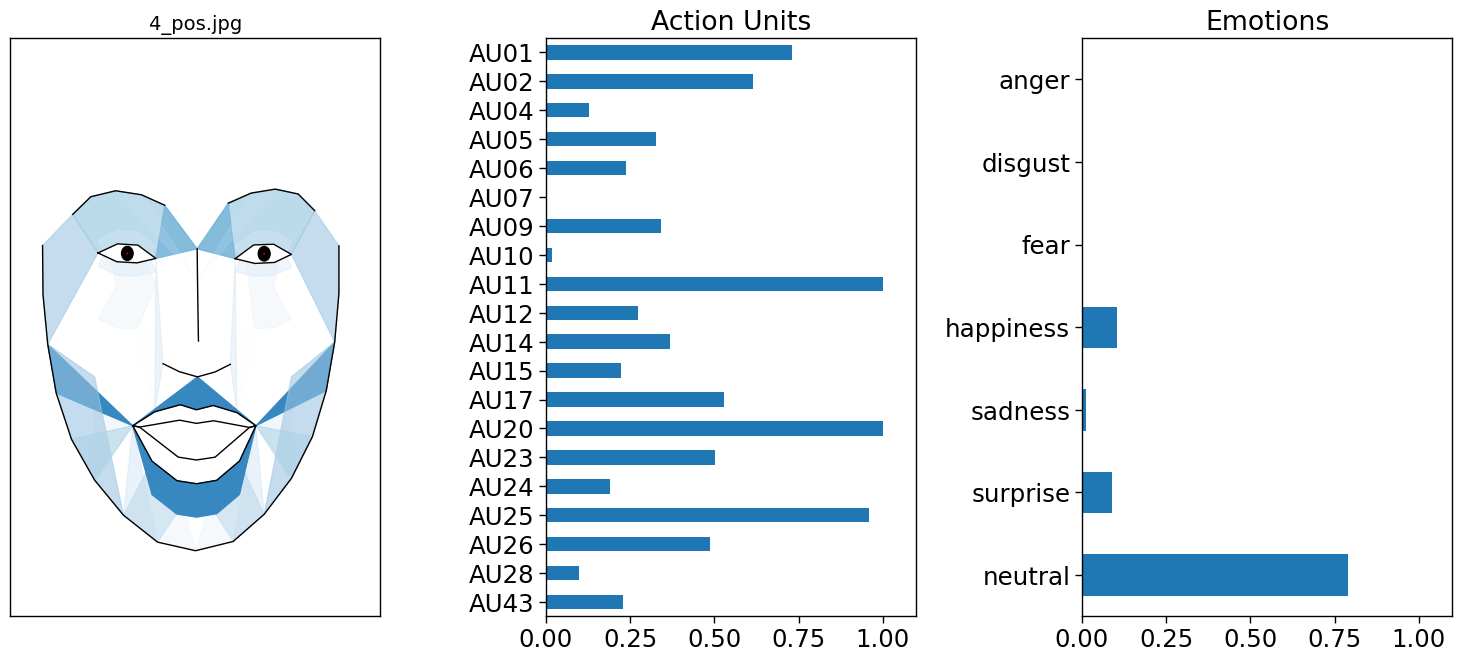

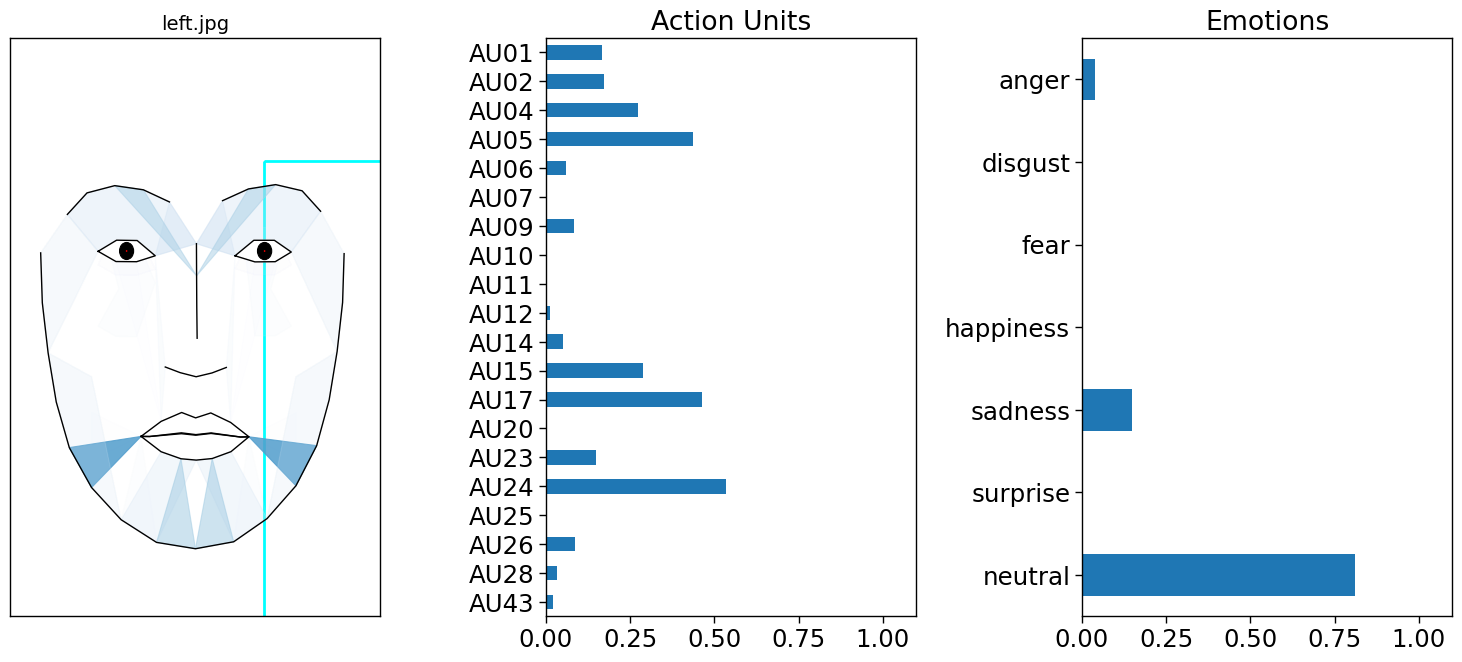

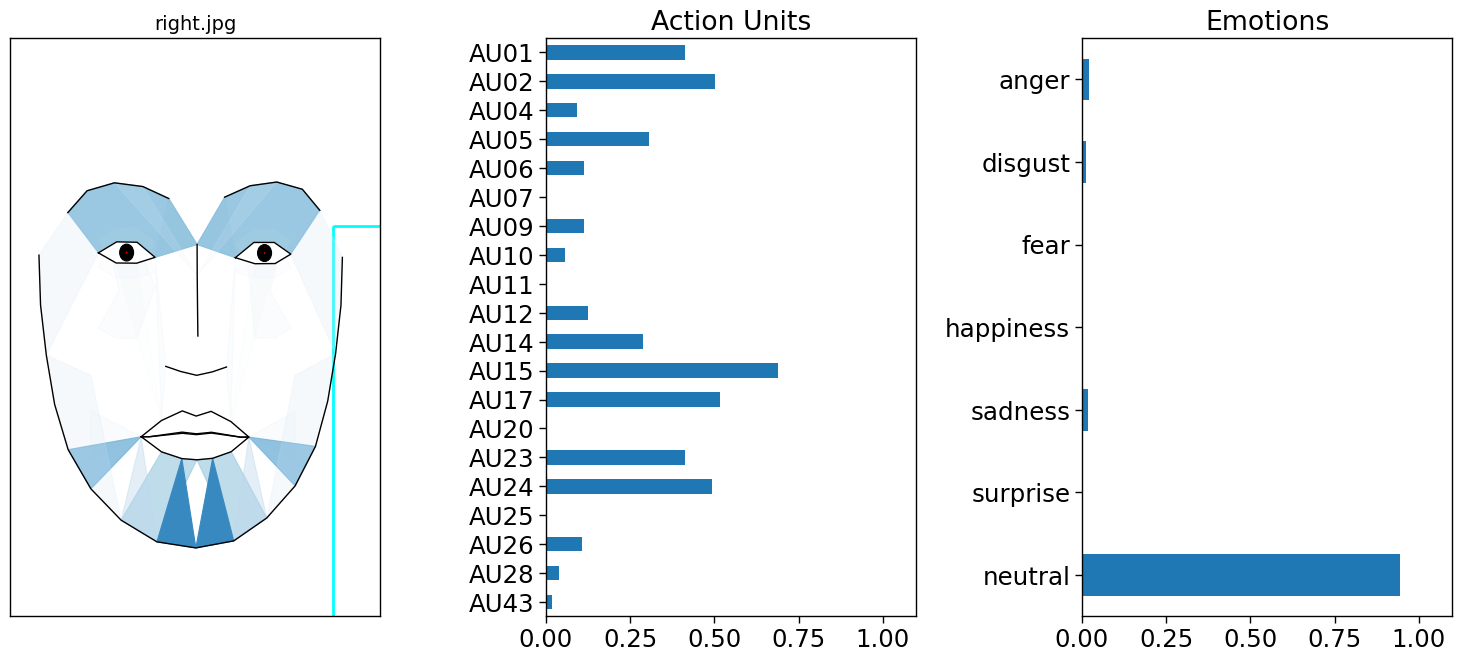

In [6]:
figs_o = single_face_prediction_original.plot_detections(faces='aus', muscles=True)
figs_l = single_face_prediction_left.plot_detections(faces='aus', muscles=True)
figs_r = single_face_prediction_right.plot_detections(faces='aus', muscles=True)

In [7]:
single_face_prediction_original.aus

,AU01,AU02,AU04,AU05,AU06,AU07,AU09,AU10,AU11,AU12,AU14,AU15,AU17,AU20,AU23,AU24,AU25,AU26,AU28,AU43
0,0.73136,0.614514,0.12915,0.327133,0.238976,0.0,0.341286,0.018156,1.0,0.273312,0.369411,0.221569,0.527318,1.0,0.500427,0.188735,0.958402,0.486071,0.097137,0.227927


In [8]:
single_face_prediction_right.aus.iloc[0]

AU01    0.413892
AU02    0.501011
AU04    0.092704
AU05    0.307201
AU06    0.113694
AU07    0.000000
AU09    0.113544
AU10    0.056970
AU11    0.000000
AU12    0.125360
AU14    0.287743
AU15    0.689414
AU17    0.515286
AU20    0.000000
AU23    0.411813
AU24    0.493134
AU25    0.002867
AU26    0.106157
AU28    0.038886
AU43    0.016963
Name: 0, dtype: float32

In [10]:
import pandas as pd

dfRight = pd.DataFrame(single_face_prediction_right.aus.iloc[0])
dfRight.columns = ['right']
dfLeft = pd.DataFrame(single_face_prediction_left.aus.iloc[0])
dfLeft.columns = ['left']
dfData = pd.merge(dfRight, dfLeft, left_index=True, right_index=True)
dfData['dif'] = dfData['right'] - dfData['left']
dfData['au'] = dfData.index
dfData

,right,left,dif,au
AU01,0.413892,0.166405,0.247486,AU01
AU02,0.501011,0.172908,0.328104,AU02
AU04,0.092704,0.272168,-0.179465,AU04
AU05,0.307201,0.436841,-0.129640,AU05
AU06,0.113694,0.058992,0.054701,AU06
AU07,0.000000,0.000000,0.000000,AU07
AU09,0.113544,0.082396,0.031148,AU09
AU10,0.056970,0.004088,0.052882,AU10
AU11,0.000000,0.000000,0.000000,AU11
AU12,0.125360,0.013311,0.112050,AU12


In [11]:
dfDataMelt = pd.melt(dfData, id_vars=['au'], value_vars=['right', 'left', 'dif'])
dfDataMelt

,au,variable,value
0,AU01,right,0.413892
1,AU02,right,0.501011
2,AU04,right,0.092704
3,AU05,right,0.307201
4,AU06,right,0.113694
5,AU07,right,0.000000
6,AU09,right,0.113544
7,AU10,right,0.056970
8,AU11,right,0.000000
9,AU12,right,0.125360


<Axes: xlabel='au', ylabel='value'>

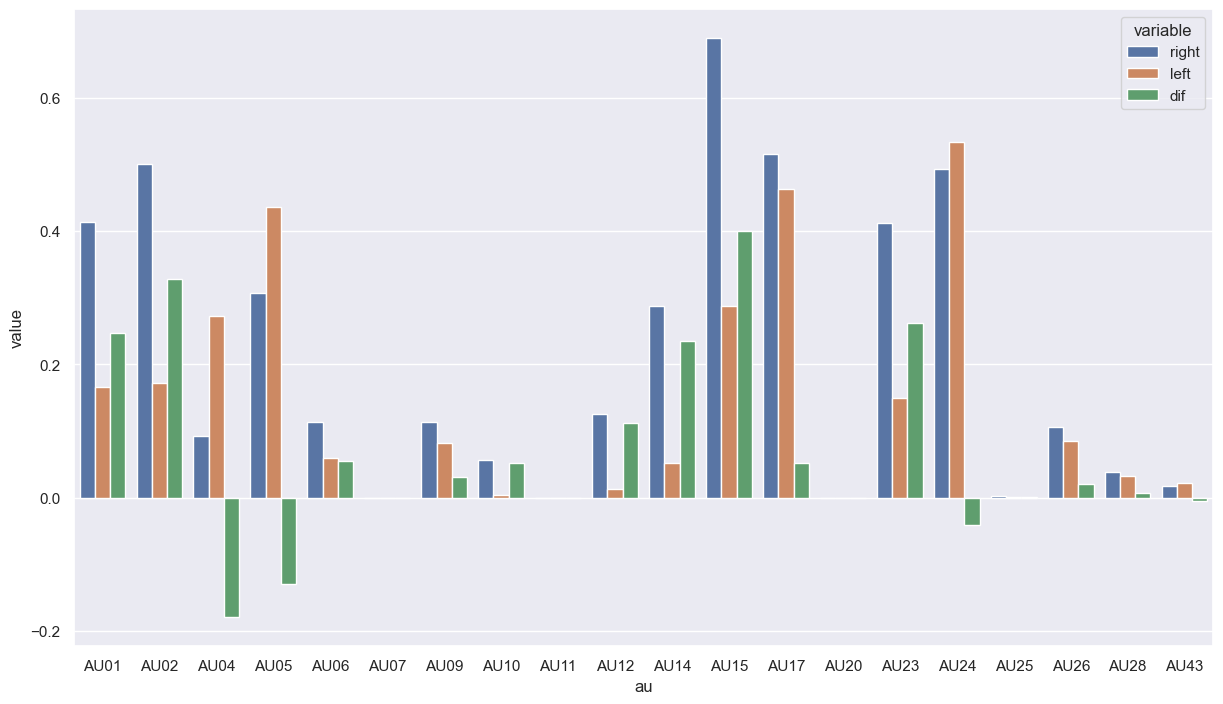

In [12]:
import seaborn as sns

sns.set(rc={'figure.figsize':(14.7,8.27)})
sns.barplot(x="au", y="value", hue="variable", data=dfDataMelt)
